In [ ]:
import numpy as np
import scipy.signal
import tensorstore as ts
from sklearn.neighbors import KDTree
import matplotlib.pyplot as plt
import asyncio
# from tqdm.asyncio import tqdm_asyncio
from mpl_toolkits.axes_grid1 import ImageGrid

## compare cell activity with zapbench trace

In [ ]:
ds = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': 'file:///groups/saalfeld/home/kumarv4/repos/zapbench/output.zarr/cell_activity'
}).result()
ds.shape

In [ ]:
act_new = ds.read().result()

In [ ]:
# Pull data from google storage since the raw data takes a while to download
gs_uri = "gs://zapbench-release/volumes/20240930"
# gs_uri = "file:///groups/saalfeld/saalfeldlab/zapbench-release/volumes/20240930"
ds = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'{gs_uri}/traces'
}).result()
ds.shape

In [ ]:
act_zap = ds.read().result()

In [ ]:
from zapbench.constants import CONDITION_OFFSETS

cell_id=1310


(0.0, 7879.0)

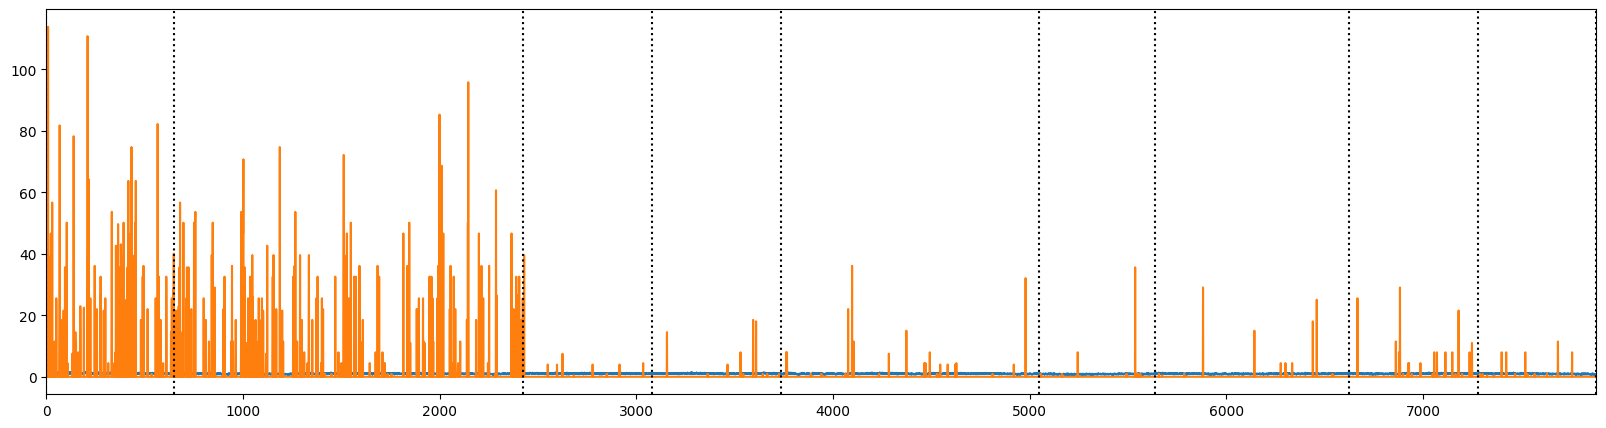

In [136]:
cell_id = 1310 #np.random.randint(71721)
print(f"{cell_id=}")

plt.figure(figsize=(20, 5))
plt.plot(act_zap[:, cell_id] / act_zap[:, cell_id].mean())
plt.plot(act_new[cell_id, :] / act_new[cell_id, :].mean())
for i in CONDITION_OFFSETS:
  plt.axvline(i, color="k", ls="dotted")

plt.xlim(0, 7879)

In [137]:
np.argmax(act_new[cell_id])

np.int64(10)

cell_id=40862


(649.0, 1049.0)

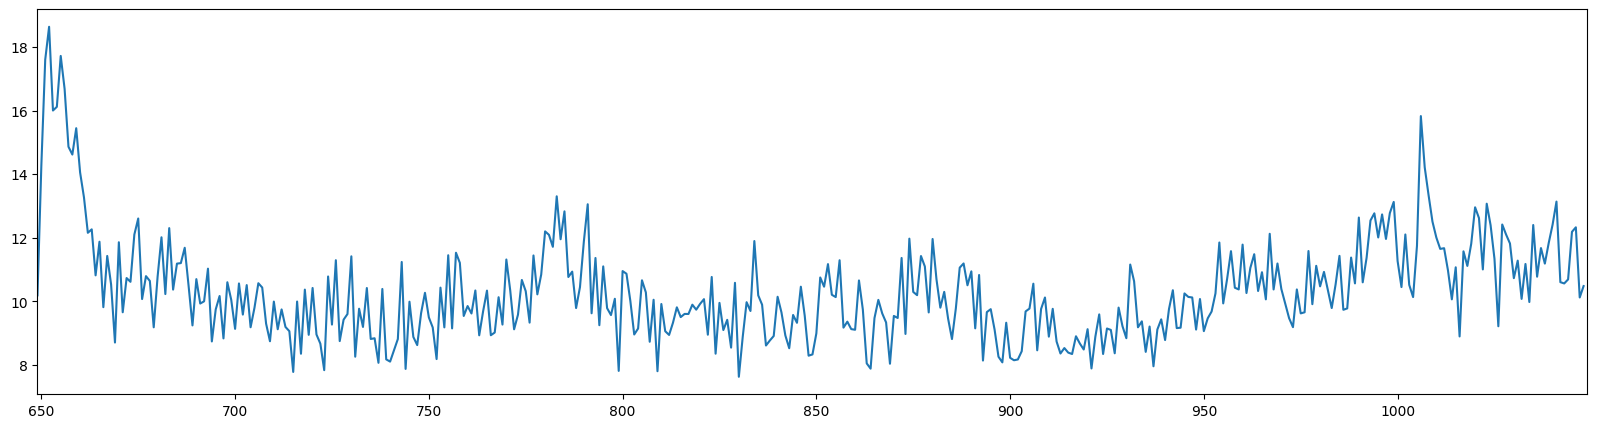

In [159]:
cell_id = np.random.randint(71721)
print(f"{cell_id=}")
# plt.scatter(
#     act_zap[:, cell_id] / act_zap[:, cell_id].max(),
#     act_new[cell_id, :] / act_new[cell_id, :].max()
# )
tmin, tmax = CONDITION_OFFSETS[1], CONDITION_OFFSETS[1]+400

plt.figure(figsize=(20, 5))
# plt.plot(np.arange(tmin, tmax), act_zap[tmin:tmax, cell_id] / act_zap[tmin:tmax, cell_id].mean())
plt.plot(np.arange(tmin, tmax), act_new[cell_id, tmin:tmax] )#/ act_new[cell_id, tmin:tmax].mean())
# for i in CONDITION_OFFSETS:
#   plt.axvline(i, color="k", ls="dotted")

plt.xlim(tmin, tmax)

Normalized noise CV (coefficient of variation of noise levels across cells):
  act_zap: mean=0.2446, std=0.1031, CV=0.42
  act_new: mean=0.3092, std=1.2406, CV=4.01

Raw noise (std of differences):
  act_zap: mean=0.03, std=0.02, CV=0.65
  act_new: mean=5.11, std=4.58, CV=0.90

Lower CV means more uniform noise across cells.


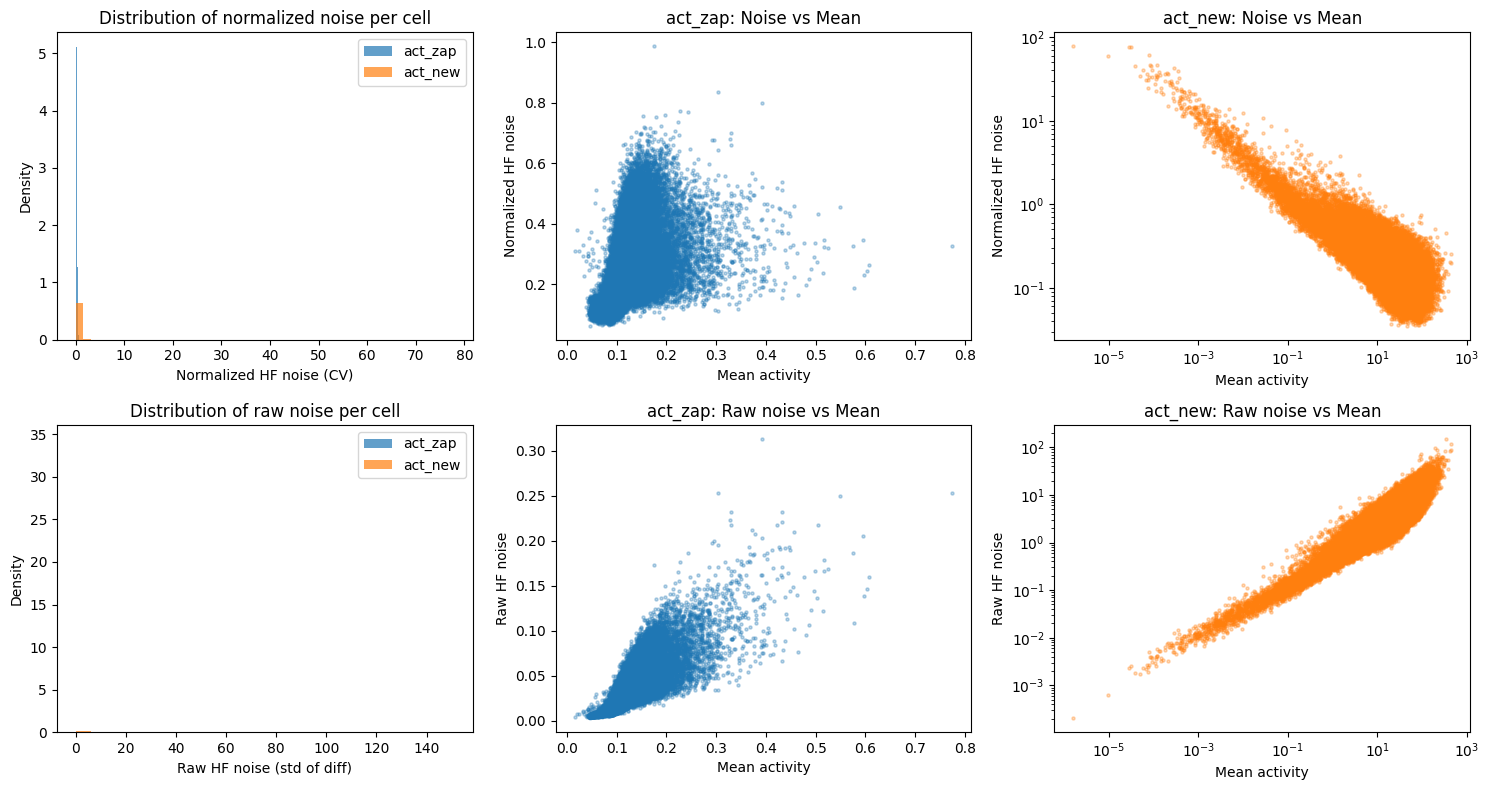

In [100]:
# Compare high-frequency noise levels between act_zap and act_new
# High-frequency noise estimated via first-order differences (approximates derivative)

# Compute high-frequency component (diff removes slow trends, keeps fast fluctuations)
hf_zap = np.diff(act_zap, axis=0)  # [T-1, cells]
hf_new = np.diff(act_new, axis=1)  # [cells, T-1]

# Noise level per cell = std of high-frequency component
# Normalize by mean signal to get coefficient of variation of noise
noise_zap = np.std(hf_zap, axis=0) / (np.mean(act_zap, axis=0) + 1e-6)
noise_new = np.std(hf_new, axis=1) / (np.mean(act_new, axis=1) + 1e-6)

# Also compute unnormalized noise (raw std of differences)
noise_zap_raw = np.std(hf_zap, axis=0)
noise_new_raw = np.std(hf_new, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 1: Normalized noise (CV of high-freq fluctuations)
ax = axes[0, 0]
ax.hist(noise_zap, bins=50, alpha=0.7, label='act_zap', density=True)
ax.hist(noise_new, bins=50, alpha=0.7, label='act_new', density=True)
ax.set_xlabel('Normalized HF noise (CV)')
ax.set_ylabel('Density')
ax.set_title('Distribution of normalized noise per cell')
ax.legend()

ax = axes[0, 1]
ax.scatter(np.mean(act_zap, axis=0), noise_zap, alpha=0.3, s=5, label='act_zap')
ax.set_xlabel('Mean activity')
ax.set_ylabel('Normalized HF noise')
ax.set_title('act_zap: Noise vs Mean')

ax = axes[0, 2]
ax.scatter(np.mean(act_new, axis=1), noise_new, alpha=0.3, s=5, label='act_new', color='C1')
ax.set_xlabel('Mean activity')
ax.set_ylabel('Normalized HF noise')
ax.set_title('act_new: Noise vs Mean')
ax.set_xscale("log")
ax.set_yscale("log")

# Row 2: Raw noise (std of differences)
ax = axes[1, 0]
ax.hist(noise_zap_raw, bins=50, alpha=0.7, label='act_zap', density=True)
ax.hist(noise_new_raw, bins=50, alpha=0.7, label='act_new', density=True)
ax.set_xlabel('Raw HF noise (std of diff)')
ax.set_ylabel('Density')
ax.set_title('Distribution of raw noise per cell')
ax.legend()

ax = axes[1, 1]
ax.scatter(np.mean(act_zap, axis=0), noise_zap_raw, alpha=0.3, s=5, label='act_zap')
ax.set_xlabel('Mean activity')
ax.set_ylabel('Raw HF noise')
ax.set_title('act_zap: Raw noise vs Mean')

ax = axes[1, 2]
ax.scatter(np.mean(act_new, axis=1), noise_new_raw, alpha=0.3, s=5, label='act_new', color='C1')
ax.set_xlabel('Mean activity')
ax.set_ylabel('Raw HF noise')
ax.set_title('act_new: Raw noise vs Mean')
ax.set_xscale("log")
ax.set_yscale("log")

plt.tight_layout()

# # Print summary statistics
print(f"Normalized noise CV (coefficient of variation of noise levels across cells):")
print(f"  act_zap: mean={noise_zap.mean():.4f}, std={noise_zap.std():.4f}, CV={noise_zap.std()/noise_zap.mean():.2f}")
print(f"  act_new: mean={noise_new.mean():.4f}, std={noise_new.std():.4f}, CV={noise_new.std()/noise_new.mean():.2f}")
print(f"\nRaw noise (std of differences):")
print(f"  act_zap: mean={noise_zap_raw.mean():.2f}, std={noise_zap_raw.std():.2f}, CV={noise_zap_raw.std()/noise_zap_raw.mean():.2f}")
print(f"  act_new: mean={noise_new_raw.mean():.2f}, std={noise_new_raw.std():.2f}, CV={noise_new_raw.std()/noise_new_raw.mean():.2f}")
print(f"\nLower CV means more uniform noise across cells.")

## check whether transform to raw zstack works

In [101]:
# Load segmentation
ds = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'{gs_uri}/segmentation'
}).result()
segmentation = ds.read().result()

In [102]:
# process segmentation to build a map between voxels and cell id's

xi, yi, zi = np.where(segmentation > 0)


# get to zero based indexing
cell_id_flat = segmentation[xi, yi, zi].astype(np.uint64)
cell_id_flat -= 1


In [103]:

# ============================================================================
# FLOW FIELDS SCHEMA
# ============================================================================
# Shape: [3, 36, 83, 128, 7879] with dimensions ["fc", "fz", "fy", "fx", "t"]
#
# The flow field stores DISPLACEMENTS (offsets) from aligned space to raw space:
#   raw_x = aligned_x + flow_fields[0, gz, gy, gx, t]
#   raw_y = aligned_y + flow_fields[1, gz, gy, gx, t]
#   raw_z = aligned_z + flow_fields[2, gz, gy, gx, t]
#
# Grid strides (aligned space -> flow field grid):
#   - stride_x = 2048 / 128 = 16
#   - stride_y = 1328 / 83  = 16
#   - stride_z = 72 / 36    = 2
# ============================================================================

# Volume dimensions
SIZE_X, SIZE_Y, SIZE_Z, SIZE_T = 2048, 1328, 72, 7879

# Flow field grid strides (aligned space pixels per grid point)
STRIDE_X = 16
STRIDE_Y = 16
STRIDE_Z = 2
ds_flow = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'{gs_uri}/flow_fields'
}).result()

# this is the raw data from the microscope
ds_raw = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': 'gs://zapbench-release/volumes/20240930/raw/'
}).result()

In [104]:
gx = xi // STRIDE_X
gy = yi // STRIDE_Y
gz = zi // STRIDE_Z
T = 1000
offset = ds_flow[:, gz, gy, gx, T].read().result()
ioffset = np.round(offset / np.array([1, 1, 4])[:, np.newaxis]).astype(int)

In [105]:
raw_coords = np.stack([xi, yi, zi], axis=0) + ioffset

raw_stack = ds_raw[:, :, :, T].read().result()
raw_vals = raw_stack[raw_coords[0], raw_coords[1], raw_coords[2]]

In [106]:


# this is the aligned data
ds_aligned = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': 'gs://zapbench-release/volumes/20240930/aligned/'
}).result()


In [148]:


ixs = np.where(cell_id_flat == 1310)

imin = xi[ixs].min()
jmin = yi[ixs].min()
z1, c1 = np.unique(zi[ixs], return_counts=True)
zbest = 30#z1[np.argmax(c1)]

In [149]:
yi[ixs].min(), yi[ixs].max()

(np.int64(248), np.int64(255))

## explore a window

(imin, jmin, T)=(1003, 501, 6964)
[ 8  2 -3]


Text(0.5, 0.98, 'Best z plane')

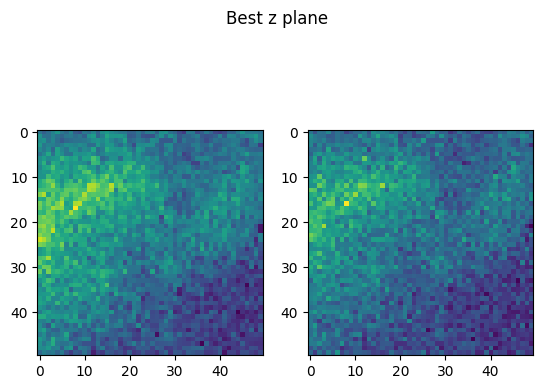

In [160]:
window = 50
# (imin, jmin, T)=(949, 1033, 3629)
imin = np.random.randint(0, 2048-window)
jmin = np.random.randint(0, 1328-window)
T = np.random.randint(7800)
imax = imin + window
# T=np.random.randint(7879)

jmax = jmin + window

print(f"{(imin, jmin, T)=}")


vol = ds_aligned[imin:imax, jmin:jmax, :, T].read().result()

zbest = np.argmax(vol.max((0, 1)))
gx = imin // STRIDE_X
gy = jmin // STRIDE_Y
gz = zbest // STRIDE_Z

offset = ds_flow[:, gz, gy, gx, T].read().result()
ioffset = np.round(offset / [1, 1, 4]).astype(int)
print(ioffset)
rimin, rimax = np.array([imin, imax]) + ioffset[0]
rjmin, rjmax = np.array([jmin, jmax]) + ioffset[1]
rzbest = zbest + ioffset[2]

raw_vol = ds_raw[rimin:rimax, rjmin:rjmax, :, T].read().result()
_, ax = plt.subplots(1, 2)
ax[0].imshow(vol[:, :, zbest])
ax[1].imshow(raw_vol[:, :, rzbest])
plt.suptitle("Best z plane")

(array([   6.,   16.,   43.,  116.,  336., 1093.,  710.,  148.,   25.,
           7.]),
 array([0.13303634, 0.20231395, 0.27159156, 0.34086918, 0.41014679,
        0.4794244 , 0.54870201, 0.61797962, 0.68725723, 0.75653484,
        0.82581246]),
 [<matplotlib.patches.Polygon at 0x76846f2589e0>])

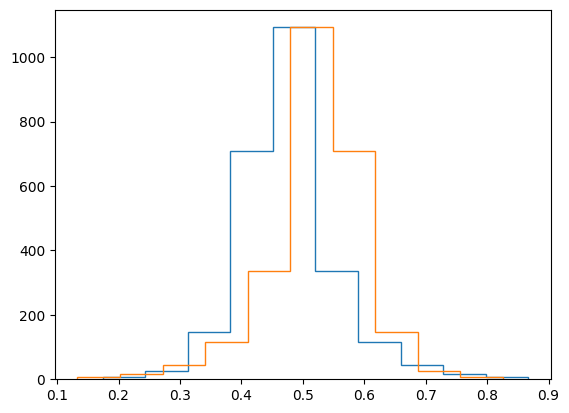

In [112]:
plt.hist(scipy.stats.poisson.sf(vol[:, :, zbest].ravel(), raw_vol[:, :, rzbest].ravel()), histtype="step")
plt.hist(scipy.stats.poisson.cdf(vol[:, :, zbest].ravel(), raw_vol[:, :, rzbest].ravel()), histtype="step")

In [ ]:
_, ax = plt.subplots(1, 2)
ax[0].imshow(vol.max(2))
ax[1].imshow(raw_vol.max(2))
plt.suptitle("MIP")